# NOTEBOOK 1 (Live 1) — Du ML au Deep Learning (ANN Dense)

### Objectifs :

* Comprendre la limite d’un modèle linéaire  

* Voir qu’un modèle ML non linéaire peut déjà bien marcher. 

* Comprendre "Pourquoi quand même du Deep Learning ?"  

* Découvrir l’API Keras/TensorFlow (Sequential, Dense, compile, fit). 

* Entraîner un ANN simple et comparer les frontières de décision. 


## 0) Imports, Setup & Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import tensorflow as tf


# Fix seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Versions:")
print(" - numpy:", np.__version__)
print(" - tensorflow:", tf.__version__)

Versions:
 - numpy: 1.26.4
 - tensorflow: 2.16.2


### Génération d’un dataset non linéaire (make_moons)
On crée un dataset 2D volontairement NON linéairement séparables.  
Intuition : une frontière "droite" ne suffira pas.


Shape X: (1200, 2)
Shape y: (1200,)
Classes: [0 1]


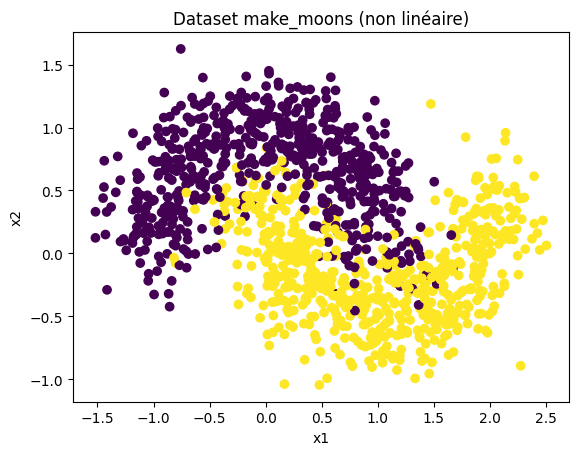

In [2]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=42)

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Classes:", np.unique(y))

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset make_moons (non linéaire)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

### Split Train/Test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (900, 2) Test: (300, 2)


### Fonction utilitaire : tracer une frontière de décision

In [5]:
def plot_decision_boundary_sklearn(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

## A. Modèles ML Classiques : Regression Logistique et SVM linéaire

### Baseline ML linéaire : Régression Logistique


=== Logistic Regression (linéaire) ===
Accuracy test: 0.8767
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       150
           1       0.90      0.85      0.87       150

    accuracy                           0.88       300
   macro avg       0.88      0.88      0.88       300
weighted avg       0.88      0.88      0.88       300



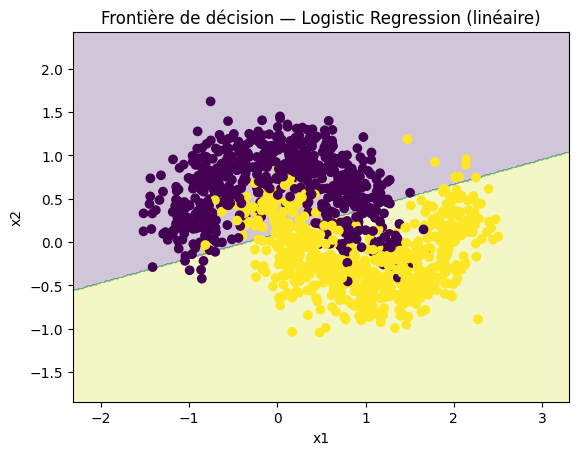

In [6]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("\n=== Logistic Regression (linéaire) ===")
print("Accuracy test:", round(acc_lr, 4))
print(classification_report(y_test, y_pred_lr))

plot_decision_boundary_sklearn(
    model=log_reg,
    X=X,
    y=y,
    title="Frontière de décision — Logistic Regression (linéaire)"
)

### Modèle ML non linéaire classique : SVM RBF


=== SVM RBF (non linéaire) ===
Accuracy test: 0.95
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       150
           1       0.96      0.94      0.95       150

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



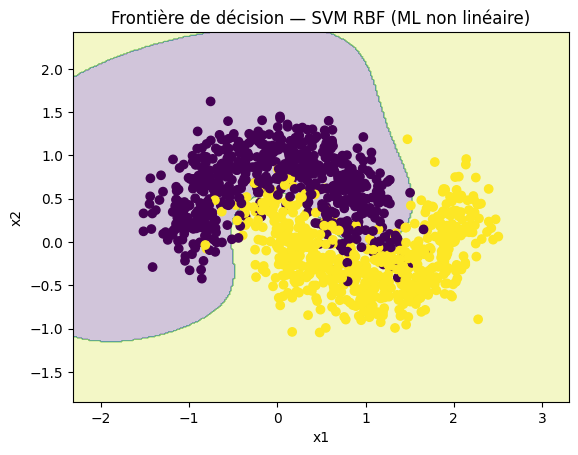

In [7]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=3.0, gamma="scale"))
])

svm_rbf.fit(X_train, y_train)

y_pred_svm = svm_rbf.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("\n=== SVM RBF (non linéaire) ===")
print("Accuracy test:", round(acc_svm, 4))
print(classification_report(y_test, y_pred_svm))

plot_decision_boundary_sklearn(
    model=svm_rbf,
    X=X,
    y=y,
    title="Frontière de décision — SVM RBF (ML non linéaire)"
)

## Pourquoi ne pas s’arrêter à un modèle non linéaire ML ?

> ### Question clé :
> ### "Si un SVM RBF marche très bien, pourquoi faire du Deep Learning ?"

### Réponse

### 1) Sur données tabulaires simples, les modèles ML non linéaires sont souvent excellents.

### 2) Mais sur données non structurées (images, audio, texte), on veut :

- #### apprendre automatiquement les représentations (features) à partir des données brutes

- #### construire des architectures modulaires (Dense, CNN, RNN, etc.)

- #### faire de l’apprentissage end-to-end (data brute -> prédiction)

### 3) Le Deep Learning est donc moins "une solution magique", et plus :

- #### un cadre flexible et scalable pour les données complexes.

> ### IMPORTANT :  
> #### On ne dit pas "DL > ML" partout.  
> #### On dit : "DL est souvent pertinent quand les features sont complexes ou non structurées."  

## B. Introduction à Keras / TensorFlow : ANN Dense simple

### Keras (dans TensorFlow) suit presque toujours le même pattern :
- #### 1) Définir le modèle (architecture)
- #### 2) Compiler (loss, optimizer, metrics)
- #### 3) Entraîner (fit)

### Ici on crée un ANN (réseau fully-connected) minimal, avec Dense

In [8]:
#Standardisation
# En deep learning, on standardise souvent les inputs pour aider l’optimisation.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Définition du modèle (Sequential + Dense)

#### Architecture :

- Dense(8, relu) : couche cachée (apprend des transformations non linéaires). 

- Dense(1, sigmoid) : sortie binaire (probabilité classe 1). 
  
> input_shape=(2,) car on a 2 features (x1, x2).

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation="relu", input_shape=(2,)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

/Users/jika/Desktop/ENSEIGMEMENT/Machine Learing/ALYRA - IA/ai-dev-teaching-hub/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-04 19:18:38.252576: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-04 19:18:38.252636: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-04 19:18:38.252646: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-04 19:18:38.252694: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 19:18:38.252709: I tensorflow/core/common_runti

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

### Compilation (optimizer, loss, metrics)

- optimizer : comment on met à jour les poids (ex: Adam)

- loss : ce qu’on cherche à minimiser (binary_crossentropy pour binaire)

- metrics : ce qu’on affiche (accuracy)

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Entraînement (fit)

- epochs : nb de passages sur le dataset

- validation_split : on garde une partie du train pour suivre la généralisation


In [11]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

print("\nTraining terminé.")

2026-03-04 19:20:32.991935: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Training terminé.


### Évaluation sur le test

In [12]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print("\n=== ANN Dense (Keras) ===")
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

# Prédictions (probas -> classes)
y_proba = model.predict(X_test_scaled, verbose=0).ravel()
y_pred_nn = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn))


=== ANN Dense (Keras) ===
Test loss: 0.3129
Test accuracy: 0.8733
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       150
           1       0.89      0.85      0.87       150

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300



### Visualisation des courbes (loss & accuracy)

- Objectif : Il faut s'habituer à lire un training.

- On approfondira callbacks / TensorBoard dans les autres notebooks. 

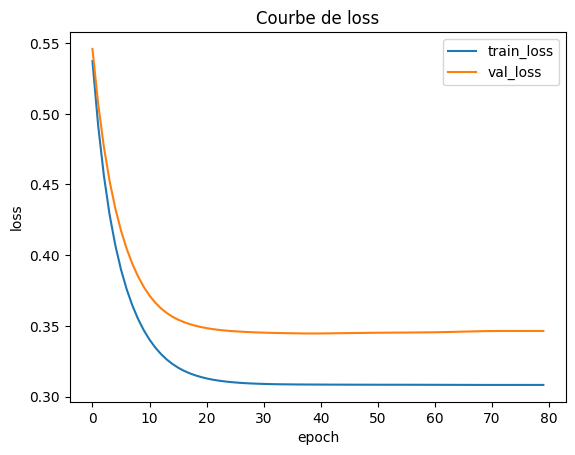

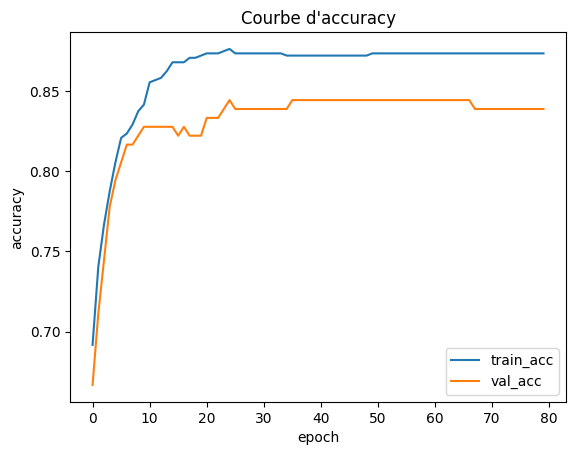

In [13]:
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Courbe de loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Courbe d'accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()


### Frontière de décision (réseau)

> #### Attention :
> - Notre réseau attend des inputs standardisés.
>
> - Dans la fonction de tracé, on standardise la grille avec le scaler déjà fit.



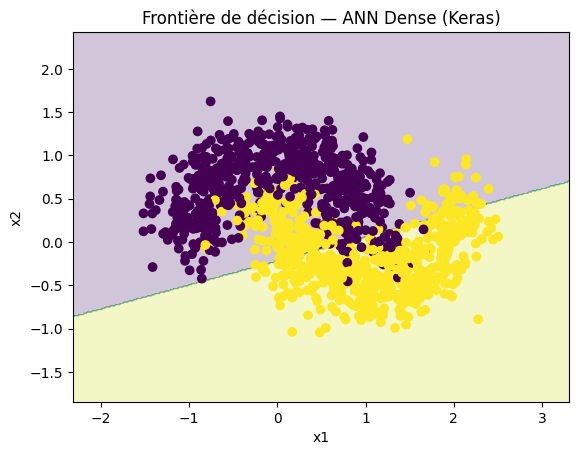

In [ ]:
def plot_decision_boundary_keras(model, scaler, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    grid_scaled = scaler.transform(grid)
    proba = model.predict(grid_scaled, verbose=0).ravel()
    Z = (proba >= 0.5).astype(int).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


plot_decision_boundary_keras(
    model=model,
    scaler=scaler,
    X=X,
    y=y,
    title="Frontière de décision — ANN Dense (Keras)"
)

## Conclusion / Messages clés

### Récapitulatif des messages clés à retenir :

-  Un modèle linéaire (LogReg) est limité par sa forme : frontière "droite".
-  Un modèle ML non linéaire (SVM RBF) peut déjà résoudre un problème courbe.
-  Le Deep Learning n’est pas "toujours meilleur", mais il est souvent pertinent quand :

    * les données sont non structurées (images, texte, audio)

    * on veut apprendre automatiquement des représentations

    * on veut construire des architectures modulaires (Dense/CNN/RNN/...)

-  Keras : pattern standard à retenir :

   1) model = Sequential([...])

   2) model.compile(optimizer, loss, metrics)

   3) history = model.fit(...)


### Mini questions (auxquelles savoir répondre pour le jury final):

1) **Pourquoi ReLU est utile dans une couche cachée ?**   
    
    La fonction ReLU (Rectified Linear Unit) est utile dans une couche cachée car elle introduit de la non-linéarité dans le modèle, ce qui permet à ce dernier d'apprendre des représentations plus complexes et abstraites des données. Sans non-linéarité, le modèle serait limité à des transformations linéaires, ce qui réduirait sa capacité d'approximation.

2) **Quelle différence entre loss et accuracy ?**   
    
    Le "loss" (perte) est une mesure de l'erreur du modèle, c'est-à-dire à quel point les prédictions du modèle sont éloignées des vraies étiquettes. L'objectif de l'entraînement est de minimiser cette perte. L'"accuracy" (précision) est une métrique qui indique le pourcentage de prédictions correctes par rapport au nombre total de prédictions. Alors que le loss est utilisé pour guider l'apprentissage, l'accuracy est souvent utilisée pour évaluer la performance globale du modèle.

3) **Que signifie "validation_split" ?**   
    
    "validation_split" est un paramètre de la méthode "fit" qui indique la proportion du jeu de données d'entraînement à utiliser comme ensemble de validation. Par exemple, si validation_split=0.2, alors 20% des données d'entraînement seront utilisées pour évaluer la performance du modèle à chaque époque, tandis que les 80% restants seront utilisés pour l'entraînement. Cela permet de suivre la généralisation du modèle pendant l'entraînement.

4) **Est-ce que le modèle overfit ? Comment le voir sur les courbes ?**  
    
    Un modèle qui overfit est un modèle qui a appris à mémoriser les données d'entraînement plutôt qu'à généraliser à de nouvelles données.  
    On peut le voir sur les courbes de loss et d'accuracy : si la courbe de loss d'entraînement continue de diminuer tandis que la courbe de loss de validation commence à augmenter, cela indique que le modèle commence à overfitter. De même, si l'accuracy d'entraînement continue d'augmenter tandis que l'accuracy de validation stagne ou diminue, cela peut également être un signe d'overfitting.